# 📈 Dự Báo Giá Cổ Phiếu VNM (Vinamilk) — Mô Hình Bi-LSTM
## Multi-step Forecasting: Dự báo 7 ngày tiếp theo từ cửa sổ 30 ngày

**Pipeline:**
1. Data Loading & Preprocessing
2. Windowing — Sliding Window (30 → 7)
3. Model Architecture — Bidirectional LSTM
4. Training với EarlyStopping + ModelCheckpoint
5. Prediction & Inverse Transform
6. Evaluation — RMSE & MAPE (tổng quan + từng ngày)
7. Visualization — Loss curve + Actual vs Predicted (fan chart)


# STAGE 0 — CÀI ĐẶT & IMPORT THƯ VIỆN


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings, os
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Bidirectional, LSTM, Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")
print(f"Pandas version     : {pd.__version__}")


2026-04-20 14:13:26.168990: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776694406.628860      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776694406.748054      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776694407.870467      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776694407.870504      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776694407.870507      23 computation_placer.cc:177] computation placer alr

TensorFlow version : 2.19.0
NumPy version      : 2.0.2
Pandas version     : 2.3.3


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/phvngtngtm/vnm-2225/VNM_2225.csv
/kaggle/input/datasets/ibrahimqasimi/global-stock-market-indices-2000-2026/Global_Stock_Market_Indices_2000_2026.csv
/kaggle/input/datasets/asadullahcreative/us-stock-market-historical-ohlcv-dataset/stock_prices_daily.csv
/kaggle/input/datasets/thangtranquang/stock-vn30-vietnam/FPT.csv
/kaggle/input/datasets/thangtranquang/stock-vn30-vietnam/VNM.csv
/kaggle/input/datasets/thangtranquang/stock-vn30-vietnam/BID.csv
/kaggle/input/datasets/thangtranquang/stock-vn30-vietnam/HPG.csv
/kaggle/input/datasets/thangtranquang/stock-vn30-vietnam/MWG.csv
/kaggle/input/datasets/thangtranquang/stock-vn30-vietnam/GVR.csv
/kaggle/input/datasets/thangtranquang/stock-vn30-vietnam/VIC.csv
/kaggle/input/datasets/thangtranquang/stock-vn30-vietnam/MBB.csv
/kaggle/input/datasets/thangtranquang/stock-vn30-vietnam/VN30.csv
/kaggle/input/datasets/thangtranquang/stock-vn30-vietnam/POW.csv
/kaggle/input/datasets/thangtranquang/stock-vn30-vietnam/PLX.csv
/kaggl

# CONFIG — Tham số toàn cục


In [3]:

DATA_PATH        = "/kaggle/input/datasets/phvngtngtm/vnm-2225/VNM_2225.csv"
FEATURES         = ["open", "high", "low", "close", "volume"]
TARGET_COL       = "close"
TARGET_IDX       = FEATURES.index(TARGET_COL)   # index = 3

TIME_STEPS       = 60    # cửa sổ nhìn vào quá khứ
FORECAST_HORIZON = 14     # số ngày dự báo

TRAIN_RATIO      = 0.80
EPOCHS           = 150
BATCH_SIZE       = 16
PATIENCE         = 20    # EarlyStopping patience

MODEL_PATH       = "best_bilstm_vnm.keras"
CHART_LOSS       = "loss_curve.png"
CHART_FORECAST   = "forecast_chart.png"

print("✅ Config loaded")
print(f"   Features        : {FEATURES}")
print(f"   Time steps      : {TIME_STEPS}")
print(f"   Forecast horizon: {FORECAST_HORIZON} days")
print(f"   Train ratio     : {TRAIN_RATIO*100:.0f}%")


✅ Config loaded
   Features        : ['open', 'high', 'low', 'close', 'volume']
   Time steps      : 60
   Forecast horizon: 14 days
   Train ratio     : 80%


# STAGE 1A — LOAD & SORT DATA


In [4]:

df = pd.read_csv(DATA_PATH)

# Chuẩn hóa tên cột về lowercase
df.columns = df.columns.str.strip().str.lower()

# Parse date & sort tăng dần theo thời gian
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Dataset shape : {df.shape}")
print(f"Date range    : {df['date'].min().date()}  →  {df['date'].max().date()}")
print()
df[FEATURES].describe().round(2)


Dataset shape : (913, 43)
Date range    : 2021-10-29  →  2025-06-30



,open,high,low,close,volume
count,913.00,913.00,913.00,913.00,913.00
mean,60.90,61.44,60.39,60.84,2926878.80
std,4.19,4.20,4.14,4.20,1947991.86
min,47.42,50.92,47.42,47.97,447884.00
25%,58.38,58.86,57.88,58.27,1672065.00
50%,60.40,60.74,59.81,60.23,2505912.00
75%,63.92,64.61,63.42,63.95,3525626.00
max,71.29,71.53,70.75,71.14,21167413.00


# STAGE 1B — TRAIN / TEST SPLIT (theo thứ tự thời gian)


In [5]:

split_idx = int(len(df) * TRAIN_RATIO)

df_train = df.iloc[:split_idx].copy()
df_test  = df.iloc[split_idx:].copy()

# Giữ lại cột date cho visualization
dates_test = df_test["date"].values

print(f"Train : {len(df_train)} rows  ({df_train['date'].min().date()} → {df_train['date'].max().date()})")
print(f"Test  : {len(df_test)}  rows  ({df_test['date'].min().date()} → {df_test['date'].max().date()})")


Train : 730 rows  (2021-10-29 → 2024-10-02)
Test  : 183  rows  (2024-10-03 → 2025-06-30)


# STAGE 1C — MINMAX SCALING (fit trên Train, transform cả hai)
- ⚠️  KHÔNG fit trên Test — tránh Data Leakage


In [6]:

scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(df_train[FEATURES].values)
test_scaled  = scaler.transform(df_test[FEATURES].values)

# Lưu mean của train (dùng cho dummy array khi inverse_transform)
train_mean_scaled = train_scaled.mean(axis=0)   # shape (5,)

print(f"train_scaled shape : {train_scaled.shape}")
print(f"test_scaled  shape : {test_scaled.shape}")
print(f"train_mean_scaled  : {train_mean_scaled.round(4)}")


train_scaled shape : (730, 5)
test_scaled  shape : (183, 5)
train_mean_scaled  : [0.5185 0.5135 0.5164 0.5312 0.1148]


# STAGE 2 — SLIDING WINDOW
-   X : (Samples, TIME_STEPS, n_features)  →  (N, 30, 5)
-   y : (Samples, FORECAST_HORIZON)         →  (N, 7)  — chỉ cột close


In [7]:

def create_sequences(data: np.ndarray,
                     time_steps: int = TIME_STEPS,
                     horizon: int = FORECAST_HORIZON,
                     target_idx: int = TARGET_IDX):
    """
    Tạo cặp (X, y) từ dữ liệu đã scaled.

    Parameters
    ----------
    data       : mảng 2D (n_rows, n_features) đã scaled
    time_steps : độ dài cửa sổ nhìn vào quá khứ
    horizon    : số bước dự báo tương lai
    target_idx : chỉ số cột target (close = 3)

    Returns
    -------
    X : np.ndarray shape (Samples, time_steps, n_features)
    y : np.ndarray shape (Samples, horizon)
    """
    X, y = [], []
    total = len(data)
    for i in range(total - time_steps - horizon + 1):
        X.append(data[i : i + time_steps])                            # (30, 5)
        y.append(data[i + time_steps : i + time_steps + horizon,
                       target_idx])                                    # (7,)
    return np.array(X), np.array(y)


X_train, y_train = create_sequences(train_scaled)

# Nối 30 ngày cuối của Train vào đầu Test để có context dự đoán ngày 1 của Test
test_scaled_extended = np.vstack((train_scaled[-TIME_STEPS:], test_scaled))

# Tạo chuỗi cho tập Test từ mảng đã nối
X_test,  y_test  = create_sequences(test_scaled_extended)

print(f"X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")


X_train : (657, 60, 5)   y_train : (657, 14)
X_test  : (170, 60, 5)    y_test  : (170, 14)


# STAGE 3 — KIẾN TRÚC MÔ HÌNH BI-LSTM


In [8]:

def build_bilstm(input_shape: tuple, output_steps: int) -> Sequential:
    """
    Xây dựng mô hình Bidirectional LSTM.

    Architecture:
        Input (30, 5)
        → BiLSTM(64, return_sequences=True) → Dropout(0.4)
        → BiLSTM(64, return_sequences=False) → Dropout(0.4)
        → Dense(32, relu)
        → Dense(7)
    """
    model = Sequential([
        Bidirectional(
            LSTM(64, return_sequences=True),
            input_shape=input_shape
        ),
        Dropout(0.4),

        Bidirectional(
            LSTM(64, return_sequences=False)
        ),
        Dropout(0.4),

        Dense(32, activation="relu"),
        Dense(output_steps)          # output: 7 ngày
    ])

    model.compile(optimizer="adam", loss="mse")
    return model


model = build_bilstm(
    input_shape=(TIME_STEPS, len(FEATURES)),
    output_steps=FORECAST_HORIZON
)
model.summary()


I0000 00:00:1776694444.296703      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776694444.302643      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 60, 128)        │        35,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           462 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139,246 (543.93 KB)

 Trainable params: 139,246 (543.93 KB)

 Non-trainable params: 0 (0.00 B)

# STAGE 4 — TRAINING


In [9]:


# --- Callbacks ---
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath=MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# --- Fit ---
# Dùng Test set làm validation để giữ nguyên 100% Train data
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print(f"\n✅ Training hoàn tất — best epoch tại val_loss thấp nhất")


Epoch 1/150


I0000 00:00:1776694450.061426      72 cuda_dnn.cc:529] Loaded cuDNN version 91002


42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1805
Epoch 1: val_loss improved from inf to 0.01514, saving model to best_bilstm_vnm.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - loss: 0.1788 - val_loss: 0.0151
Epoch 2/150
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0343
Epoch 2: val_loss did not improve from 0.01514
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0340 - val_loss: 0.0218
Epoch 3/150
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0224
Epoch 3: val_loss did not improve from 0.01514
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0224 - val_loss: 0.0185
Epoch 4/150
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0189
Epoch 4: val_loss improved from 0.01514 to 0.01360, saving model to best_bilstm_vnm.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0189 - val_loss: 0.0136
Epoch 5/150
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0185
Epoch 5: val_loss did not improve from 0.01360
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0185 - val_los

# STAGE 5A — HÀM INVERSE TRANSFORM (xử lý kỹ thuật)

- **Vấn đề:** `scaler` fit trên **5 cột**, nhưng `y` chỉ có **1 cột** (close).
- **Giải pháp:** 
    1. Tạo **dummy array** $(N, 5)$.
    2. Lấp đầy bằng `train_mean_scaled`.
    3. Thay đúng cột `TARGET_IDX` bằng giá trị cần đảo ngược.
    4. Chạy `inverse_transform` → lấy cột `TARGET_IDX` ra.


In [10]:

def inverse_close(scaled_values: np.ndarray,
                  scaler: MinMaxScaler,
                  mean_scaled: np.ndarray,
                  target_idx: int = TARGET_IDX) -> np.ndarray:
    """
    Đảo ngược MinMaxScaler cho mảng 1D hoặc 2D chứa giá trị close đã scaled.

    Parameters
    ----------
    scaled_values : shape (N,) hoặc (N, horizon)
    scaler        : scaler đã fit trên train
    mean_scaled   : giá trị trung bình scaled của train set — shape (5,)
    target_idx    : chỉ số cột close trong feature list

    Returns
    -------
    np.ndarray cùng shape với scaled_values, đơn vị VNĐ gốc
    """
    original_shape = scaled_values.shape
    flat = scaled_values.reshape(-1)          # (N*horizon,) hoặc (N,)

    # Tạo dummy array: mỗi hàng = train_mean_scaled
    dummy = np.tile(mean_scaled, (len(flat), 1))   # (len, 5)
    dummy[:, target_idx] = flat                    # thay cột close

    inversed = scaler.inverse_transform(dummy)[:, target_idx]
    return inversed.reshape(original_shape)


print("✅ Hàm inverse_close đã sẵn sàng")


✅ Hàm inverse_close đã sẵn sàng


# STAGE 5B — DỰ ĐOÁN & INVERSE TRANSFORM


In [11]:
# ============================================================
# STAGE 5B — DỰ ĐOÁN & INVERSE TRANSFORM
# ============================================================
y_pred_scaled = model.predict(X_test, verbose=0)   # (N_test, 7)

# Đảo ngược về VNĐ
y_pred = inverse_close(y_pred_scaled, scaler, train_mean_scaled)   # (N_test, 7)
y_true = inverse_close(y_test,        scaler, train_mean_scaled)   # (N_test, 7)

print(f"y_pred shape : {y_pred.shape}")
print(f"y_true shape : {y_true.shape}")
print(f"\nMẫu y_true[0] (VNĐ) : {y_true[0].round(0)}")
print(f"Mẫu y_pred[0] (VNĐ) : {y_pred[0].round(0)}")


y_pred shape : (170, 14)
y_true shape : (170, 14)

Mẫu y_true[0] (VNĐ) : [64. 63. 61. 62. 62. 62. 62. 62. 61. 62. 62. 62. 62. 62.]
Mẫu y_pred[0] (VNĐ) : [64. 63. 63. 63. 62. 63. 63. 63. 62. 62. 63. 63. 63. 63.]


# STAGE 6 — ĐÁNH GIÁ MÔ HÌNH


In [12]:
def rmse(actual, predicted):
    return np.sqrt(mean_squared_error(actual, predicted))

def mape(actual, predicted):
    # Tránh chia cho 0
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100


# --- Tổng quan (flatten toàn bộ 7 ngày) ---
overall_rmse = rmse(y_true.flatten(), y_pred.flatten())
overall_mape = mape(y_true.flatten(), y_pred.flatten())

print("=" * 50)
print("  ĐÁNH GIÁ TỔNG QUAN (trên toàn bộ 14 ngày dự báo)")
print("=" * 50)
print(f"  RMSE : {overall_rmse:,.2f} VNĐ")
print(f"  MAPE : {overall_mape:.2f} %")
print()

# --- Chi tiết từng ngày ---
print("=" * 50)
print("  ĐÁNH GIÁ CHI TIẾT TỪNG NGÀY")
print("=" * 50)
print(f"  {'Ngày':<8}  {'RMSE (VNĐ)':>14}  {'MAPE (%)':>10}")
print("  " + "-" * 36)

daily_rmse = []
daily_mape = []
for d in range(FORECAST_HORIZON):
    r = rmse(y_true[:, d], y_pred[:, d])
    m = mape(y_true[:, d], y_pred[:, d])
    daily_rmse.append(r)
    daily_mape.append(m)
    print(f"  Day {d+1:<3}   {r:>14,.2f}   {m:>10.2f}")

print("=" * 50)


  ĐÁNH GIÁ TỔNG QUAN (trên toàn bộ 14 ngày dự báo)
  RMSE : 2.30 VNĐ
  MAPE : 3.14 %

  ĐÁNH GIÁ CHI TIẾT TỪNG NGÀY
  Ngày          RMSE (VNĐ)    MAPE (%)
  ------------------------------------
  Day 1               1.84         2.46
  Day 2               2.02         2.66
  Day 3               2.04         2.70
  Day 4               1.98         2.66
  Day 5               2.18         2.98
  Day 6               2.28         3.14
  Day 7               2.12         2.91
  Day 8               1.94         2.64
  Day 9               2.37         3.27
  Day 10              2.44         3.37
  Day 11              2.91         4.14
  Day 12              2.63         3.67
  Day 13              2.48         3.47
  Day 14              2.73         3.89


# STAGE 7A — BIỂU ĐỒ 1: TRAINING LOSS vs VALIDATION LOSS


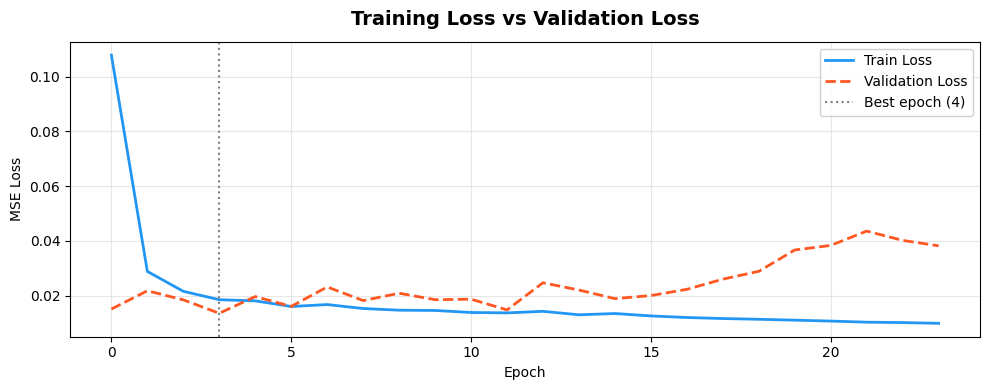

✅ Đã lưu: loss_curve.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(history.history["loss"],     label="Train Loss",      color="#2196F3", linewidth=2)
ax.plot(history.history["val_loss"], label="Validation Loss", color="#FF5722",
        linewidth=2, linestyle="--")

best_ep = np.argmin(history.history["val_loss"])
ax.axvline(best_ep, color="gray", linestyle=":", linewidth=1.5,
           label=f"Best epoch ({best_ep+1})")

ax.set_title("Training Loss vs Validation Loss", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CHART_LOSS, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Đã lưu: {CHART_LOSS}")


# STAGE 7B — BIỂU ĐỒ 2: ACTUAL vs PREDICTED (Fan Chart)

### 📈 Cách vẽ:
*   **Đường Actual:** Liền mạch toàn bộ Test set.
*   **Đường Day 1:** Đường dự báo chính (dùng để so sánh gần nhất).
*   **Fan branches:** Chọn 3 điểm (đầu/giữa/cuối) → vẽ nhánh dự báo 7 ngày.

> **Lưu ý về dữ liệu Actual:**
> Actual close price được vẽ liên tục trên toàn Test (dùng `y_true` Day 1 làm proxy). 
> Vì mỗi sample trong `y_true` là 7 ngày liên tiếp, ta lấy **Day 1** của từng sample → xấp xỉ đường actual trượt theo cửa sổ.


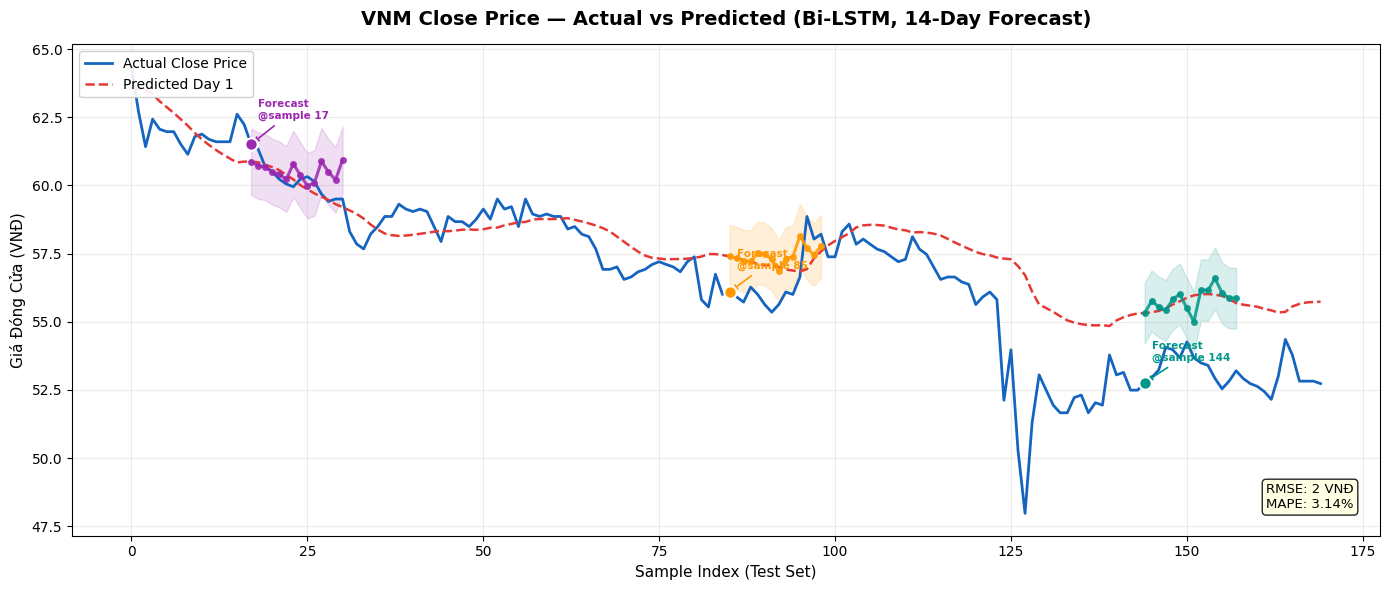

✅ Đã lưu: forecast_chart.png


In [14]:
actual_day1 = y_true[:, 0]   # giá thực tế ngày đầu của mỗi cửa sổ
pred_day1   = y_pred[:, 0]   # giá dự báo ngày 1

n_samples = len(actual_day1)
x_axis    = np.arange(n_samples)

# 3 điểm để vẽ fan branch: đầu (10%), giữa (50%), cuối (85%)
branch_indices = [
    int(n_samples * 0.10),
    int(n_samples * 0.50),
    int(n_samples * 0.85),
]
branch_colors = ["#9C27B0", "#FF9800", "#009688"]

fig, ax = plt.subplots(figsize=(14, 6))

# --- Actual ---
ax.plot(x_axis, actual_day1,
        color="#1565C0", linewidth=2.0,
        label="Actual Close Price", zorder=3)

# --- Predicted Day 1 ---
ax.plot(x_axis, pred_day1,
        color="#E53935", linewidth=1.8, linestyle="--",
        label="Predicted Day 1", zorder=3)

# --- Fan branches (7 ngày tỏa ra từ 3 điểm) ---
for idx, color in zip(branch_indices, branch_colors):
    branch_x = np.arange(idx, idx + FORECAST_HORIZON)
    branch_y = y_pred[idx]                 # 7 giá trị dự báo

    # Đường nhánh
    ax.plot(branch_x, branch_y,
            color=color, linewidth=2.2, marker="o", markersize=4,
            zorder=4, alpha=0.85)

    # Vùng tô nhạt (uncertainty band giả định ±2%)
    upper = branch_y * 1.02
    lower = branch_y * 0.98
    ax.fill_between(branch_x, lower, upper,
                    color=color, alpha=0.15)

    # Điểm bắt đầu nhánh
    ax.scatter(idx, actual_day1[idx],
               color=color, s=80, zorder=5,
               edgecolors="white", linewidths=1.5)

    # Label
    ax.annotate(f"Forecast\n@sample {idx}",
                xy=(idx, actual_day1[idx]),
                xytext=(idx + 1, actual_day1[idx] + actual_day1[idx]*0.015),
                fontsize=7.5, color=color, fontweight="bold",
                arrowprops=dict(arrowstyle="->", color=color, lw=1.2))

# --- Decorations ---
ax.set_title(
    "VNM Close Price — Actual vs Predicted (Bi-LSTM, 14-Day Forecast)",
    fontsize=14, fontweight="bold", pad=14
)
ax.set_xlabel("Sample Index (Test Set)", fontsize=11)
ax.set_ylabel("Giá Đóng Cửa (VNĐ)", fontsize=11)
ax.legend(loc="upper left", framealpha=0.9, fontsize=10)
ax.grid(True, alpha=0.25)

# Thêm text metrics lên chart
textstr = f"RMSE: {overall_rmse:,.0f} VNĐ\nMAPE: {overall_mape:.2f}%"
props   = dict(boxstyle="round", facecolor="lightyellow", alpha=0.85)
ax.text(0.98, 0.05, textstr, transform=ax.transAxes, fontsize=9.5,
        verticalalignment="bottom", horizontalalignment="right",
        bbox=props)

plt.tight_layout()
plt.savefig(CHART_FORECAST, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Đã lưu: {CHART_FORECAST}")


# STAGE 7C — BIỂU ĐỒ 3: RMSE & MAPE THEO TỪNG NGÀY (FIXED)


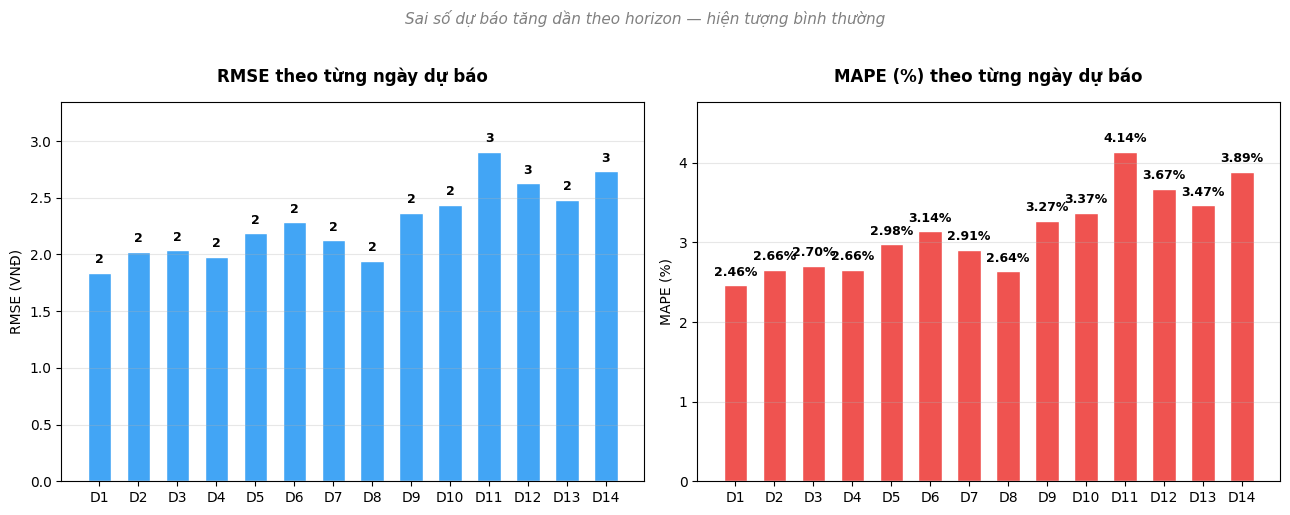

In [15]:
days = [f"D{i+1}" for i in range(FORECAST_HORIZON)]
x    = np.arange(FORECAST_HORIZON)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5)) # Tăng nhẹ chiều cao

# --- RMSE bar ---
bars1 = ax1.bar(x, daily_rmse, width=0.6, color="#42A5F5", edgecolor="white")
ax1.set_title("RMSE theo từng ngày dự báo", fontweight="bold", pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(days)
ax1.set_ylabel("RMSE (VNĐ)")
ax1.grid(axis="y", alpha=0.3)

# Fix trục Y: lấy max + 15% để tránh chữ bị đè hoặc khoảng trắng thừa
ax1.set_ylim(0, max(daily_rmse) * 1.15) 

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + (max(daily_rmse)*0.02),
             f"{height:,.0f}", ha="center", va="bottom", fontsize=9, fontweight='bold')

# --- MAPE bar ---
bars2 = ax2.bar(x, daily_mape, width=0.6, color="#EF5350", edgecolor="white")
ax2.set_title("MAPE (%) theo từng ngày dự báo", fontweight="bold", pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(days)
ax2.set_ylabel("MAPE (%)")
ax2.grid(axis="y", alpha=0.3)

# Fix trục Y tương tự cho MAPE
ax2.set_ylim(0, max(daily_mape) * 1.15)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + (max(daily_mape)*0.02),
             f"{height:.2f}%", ha="center", va="bottom", fontsize=9, fontweight='bold')

plt.suptitle("Sai số dự báo tăng dần theo horizon — hiện tượng bình thường",
             fontsize=11, style="italic", color="gray", y=1.02)

plt.tight_layout()
plt.savefig("daily_error_chart_fixed.png", dpi=150, bbox_inches="tight")
plt.show()

# TÓM TẮT KẾT QUẢ


In [16]:
print("=" * 55)
print("   KẾT QUẢ CUỐI CÙNG — VNM Bi-LSTM Forecasting")
print("=" * 55)
print(f"   Model        : 2x Bidirectional LSTM (64 units)")
print(f"   Input shape  : ({TIME_STEPS}, {len(FEATURES)})")
print(f"   Output shape : ({FORECAST_HORIZON},) — dự báo {FORECAST_HORIZON} ngày")
print(f"   Best epoch   : {np.argmin(history.history['val_loss']) + 1}")
print(f"   RMSE (avg)   : {overall_rmse:,.2f} VNĐ")
print(f"   MAPE (avg)   : {overall_mape:.2f} %")
print("=" * 55)
print()
print(" Files đã xuất:")
print(f"   - {MODEL_PATH}")
print(f"   - {CHART_LOSS}")
print(f"   - {CHART_FORECAST}")
print(f"   - daily_error_chart.png")


   KẾT QUẢ CUỐI CÙNG — VNM Bi-LSTM Forecasting
   Model        : 2x Bidirectional LSTM (64 units)
   Input shape  : (60, 5)
   Output shape : (14,) — dự báo 14 ngày
   Best epoch   : 4
   RMSE (avg)   : 2.30 VNĐ
   MAPE (avg)   : 3.14 %

 Files đã xuất:
   - best_bilstm_vnm.keras
   - loss_curve.png
   - forecast_chart.png
   - daily_error_chart.png


# CẤU HÌNH KIỂM THỬ (1) - GLOBAL STOCK INDICES 
- Link dataset: https://www.kaggle.com/datasets/ibrahimqasimi/global-stock-market-indices-2000-2026

--- Đang tải model từ: /kaggle/working/best_bilstm_vnm.keras ---
--- Đang đọc dữ liệu toàn cầu: /kaggle/input/datasets/ibrahimqasimi/global-stock-market-indices-2000-2026/Global_Stock_Market_Indices_2000_2026.csv ---

Index           | RMSE (Points)   | MAPE (%)  
---------------------------------------------
^GSPC           |         1259.51 |      18.54%
^DJI            |         8544.25 |      17.84%
^IXIC           |         5525.79 |      24.34%
^FTSE           |         1405.86 |      14.01%
^N225           |         8495.04 |      16.11%
^GDAXI          |         5756.17 |      23.51%
^FCHI           |         1364.19 |      16.71%
^HSI            |         2611.21 |       9.49%
^BSESN          |        22558.45 |      26.99%
000001.SS       |          425.39 |      10.43%
^KS11           |          694.27 |      12.42%
^BVSP           |        35364.33 |      21.64%
^GSPTSE         |         5042.79 |      15.85%
^AXJO           |         1159.46 |      12.98%


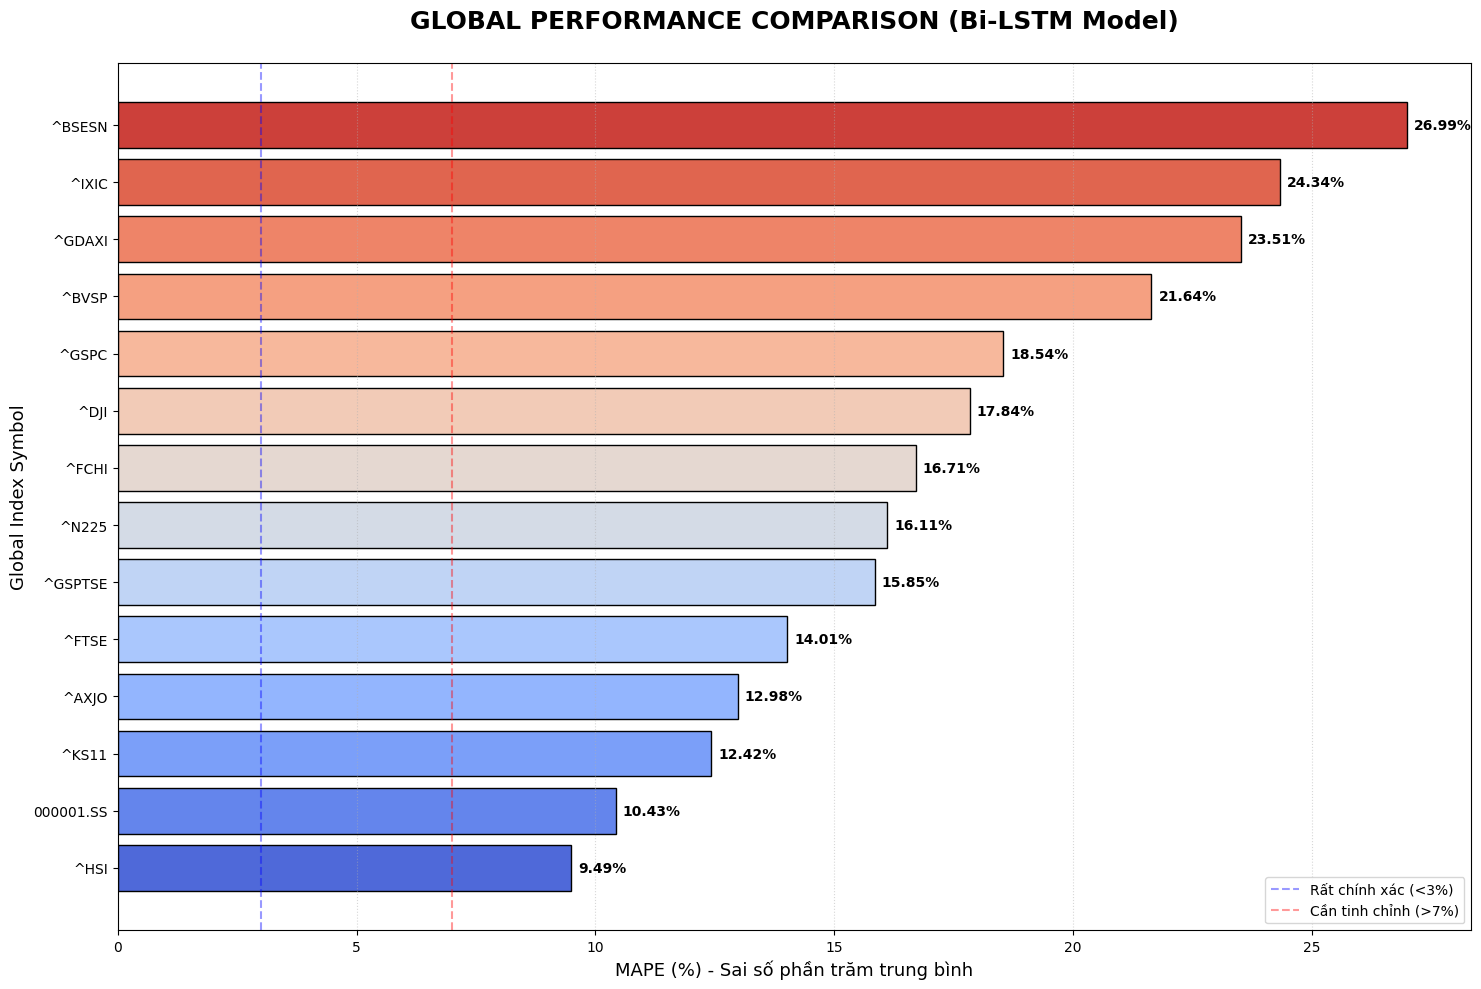


 MAPE TRUNG BÌNH TOÀN CẦU: 17.20%


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

MODEL_PATH = '/kaggle/working/best_bilstm_vnm.keras'
FILE_PATH = '/kaggle/input/datasets/ibrahimqasimi/global-stock-market-indices-2000-2026/Global_Stock_Market_Indices_2000_2026.csv'
TIME_STEPS = 30
FEATURES = ['open', 'high', 'low', 'close', 'volume']
TARGET_IDX = 3 

# 1. Load model
print(f"--- Đang tải model từ: {MODEL_PATH} ---")
model = load_model(MODEL_PATH)

# 2. Đọc dữ liệu
print(f"--- Đang đọc dữ liệu toàn cầu: {FILE_PATH} ---")
df_global = pd.read_csv(FILE_PATH)
df_global.columns = [c.lower() for c in df_global.columns]
ticker_col = 'symbol' if 'symbol' in df_global.columns else 'ticker'

def evaluate_index(name, group_df):
    try:
        group_df = group_df.sort_values('date')
        data = group_df[FEATURES].values
        data = data[~np.any(data <= 0, axis=1)] # Bỏ các dòng lỗi
        
        if len(data) < (TIME_STEPS + FORECAST_HORIZON + 100):
            return None
            
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaled_data = scaler.fit_transform(data)
        
        X, y_true_scaled = [], []
        for i in range(len(scaled_data) - TIME_STEPS - FORECAST_HORIZON + 1):
            X.append(scaled_data[i : i + TIME_STEPS])
            y_true_scaled.append(scaled_data[i + TIME_STEPS : i + TIME_STEPS + FORECAST_HORIZON, TARGET_IDX])
            
        X = np.array(X)
        y_true_scaled = np.array(y_true_scaled)
        
        y_pred_scaled = model.predict(X, verbose=0, batch_size=1024)
        
        def inverse_y(y_s):
            y_i = []
            samples = y_s[-200:] # Lấy 200 mẫu cuối để đại diện
            for s in samples:
                dummy = np.zeros((FORECAST_HORIZON, len(FEATURES)))
                dummy[:, TARGET_IDX] = s
                y_i.append(scaler.inverse_transform(dummy)[:, TARGET_IDX])
            return np.array(y_i)

        y_true = inverse_y(y_true_scaled)
        y_pred = inverse_y(y_pred_scaled)
        
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        return rmse, mape
    except:
        return None

# 3. Chạy kiểm thử và thu thập dữ liệu vẽ biểu đồ
indices = df_global[ticker_col].unique()
results_list = []

print(f"\n{'Index':<15} | {'RMSE (Points)':<15} | {'MAPE (%)':<10}")
print("-" * 45)

for idx in indices:
    group = df_global[df_global[ticker_col] == idx]
    metrics = evaluate_index(idx, group)
    if metrics:
        rmse, mape = metrics
        results_list.append({"Index": idx, "RMSE": rmse, "MAPE": mape})
        print(f"{idx:<15} | {rmse:15.2f} | {mape:10.2f}%")

# ============================================================
# 4. VẼ BIỂU ĐỒ TỔNG HỢP TOÀN CẦU
# ============================================================
if results_list:
    df_res = pd.DataFrame(results_list).sort_values('MAPE')

    plt.figure(figsize=(15, 10))
    # Palette màu trực quan: Xanh cho chuẩn, Vàng/Đỏ cho sai số cao
    colors = sns.color_palette("coolwarm", len(df_res))
    bars = plt.barh(df_res['Index'], df_res['MAPE'], color=colors, edgecolor='black')
    
    # Kẻ các đường tham chiếu quan trọng
    plt.axvline(x=3, color='blue', linestyle='--', alpha=0.4, label='Rất chính xác (<3%)')
    plt.axvline(x=7, color='red', linestyle='--', alpha=0.4, label='Cần tinh chỉnh (>7%)')
    
    plt.title("GLOBAL PERFORMANCE COMPARISON (Bi-LSTM Model)", fontsize=18, fontweight='bold', pad=25)
    plt.xlabel("MAPE (%) - Sai số phần trăm trung bình", fontsize=13)
    plt.ylabel("Global Index Symbol", fontsize=13)
    plt.legend(loc='lower right')
    plt.grid(axis='x', linestyle=':', alpha=0.5)

    # Hiển thị text thông số
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.15, bar.get_y() + bar.get_height()/2, 
                 f'{width:.2f}%', va='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print(f"\n MAPE TRUNG BÌNH TOÀN CẦU: {df_res['MAPE'].mean():.2f}%")

# CẤU HÌNH KIỂM THỬ (2) - US STOCK
- Link dataset: https://www.kaggle.com/datasets/asadullahcreative/us-stock-market-historical-ohlcv-dataset

--- Đang tải model từ: /kaggle/working/best_bilstm_vnm.keras ---
--- Đang đọc file dữ liệu: /kaggle/input/datasets/asadullahcreative/us-stock-market-historical-ohlcv-dataset/stock_prices_daily.csv ---

Ticker     | RMSE ($)     | MAPE (%)  
----------------------------------------
AAPL       |        54.66 |      20.23%
ABBV       |        43.89 |      19.23%
ABT        |        16.34 |      12.09%
ADBE       |        53.72 |      15.10%
AIG        |        14.47 |      17.16%
AMAT       |        47.14 |      14.99%
AMD        |        45.00 |      17.02%
AMGN       |        36.74 |      10.10%
AMZN       |        37.25 |      15.25%
APD        |        17.58 |       5.61%
AVGO       |        76.41 |      20.36%
AXP        |        75.23 |      20.49%
BA         |        18.97 |       7.15%
BAC        |         9.22 |      16.96%
BIIB       |        31.24 |      18.67%
BLK        |       217.22 |      19.19%
BMY        |         2.75 |       4.94%
BRK-B      |        74.29 |      14.70

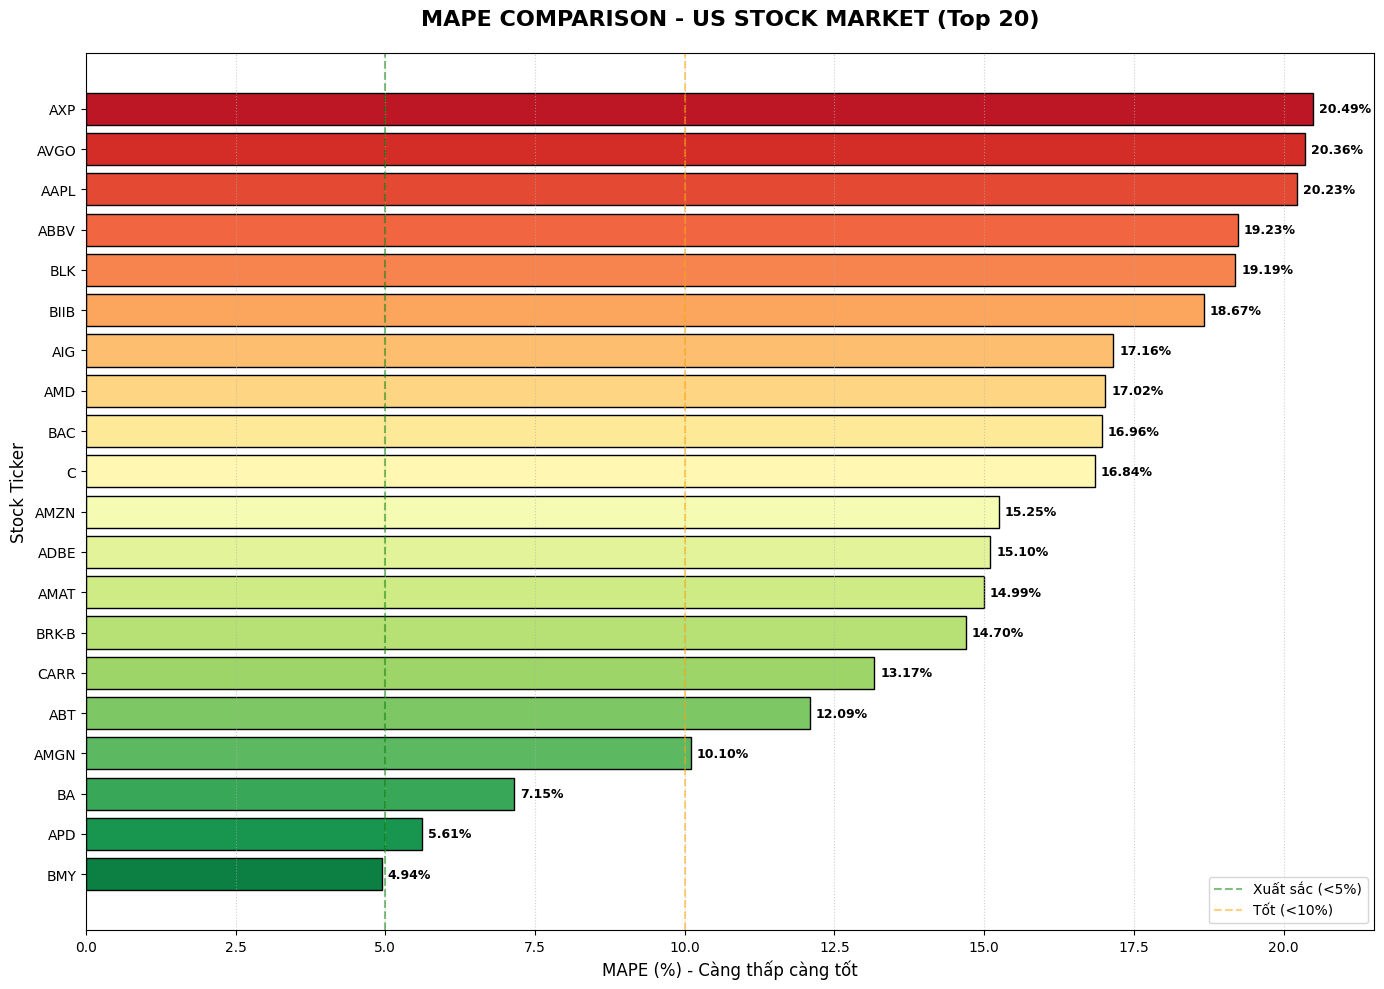


✅ MAPE TRUNG BÌNH CỦA NHÓM: 14.96%


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error


MODEL_PATH = '/kaggle/working/best_bilstm_vnm.keras'
FILE_PATH = '/kaggle/input/datasets/asadullahcreative/us-stock-market-historical-ohlcv-dataset/stock_prices_daily.csv'
TIME_STEPS = 30
FEATURES = ['open', 'high', 'low', 'close', 'volume']
TARGET_IDX = 3 

# 1. Load model
print(f"--- Đang tải model từ: {MODEL_PATH} ---")
model = load_model(MODEL_PATH)

# 2. Đọc file tổng hợp
print(f"--- Đang đọc file dữ liệu: {FILE_PATH} ---")
df_all = pd.read_csv(FILE_PATH)
df_all.columns = [c.lower() for c in df_all.columns]
ticker_col = 'ticker' if 'ticker' in df_all.columns else 'symbol'

def evaluate_group(ticker_name, group_df):
    try:
        group_df = group_df.sort_values('date')
        data = group_df[FEATURES].values
        
        if len(data) < (TIME_STEPS + FORECAST_HORIZON + 50):
            return None
            
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaled_data = scaler.fit_transform(data)
        
        X, y_true_scaled = [], []
        for i in range(len(scaled_data) - TIME_STEPS - FORECAST_HORIZON + 1):
            X.append(scaled_data[i : i + TIME_STEPS])
            y_true_scaled.append(scaled_data[i + TIME_STEPS : i + TIME_STEPS + FORECAST_HORIZON, TARGET_IDX])
            
        X = np.array(X)
        y_true_scaled = np.array(y_true_scaled)
        
        y_pred_scaled = model.predict(X, verbose=0, batch_size=1024)
        
        def fast_inverse(y_s):
            y_i = []
            samples_to_eval = y_s[-100:] 
            for sample in samples_to_eval:
                dummy = np.zeros((FORECAST_HORIZON, len(FEATURES)))
                dummy[:, TARGET_IDX] = sample
                y_i.append(scaler.inverse_transform(dummy)[:, TARGET_IDX])
            return np.array(y_i)

        y_true = fast_inverse(y_true_scaled)
        y_pred = fast_inverse(y_pred_scaled)
        
        mask = y_true > 0.01
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        
        return rmse, mape
    except:
        return None

# 3. Chạy lặp và thu thập kết quả
tickers = df_all[ticker_col].unique()[:20] # Chạy thử 20 mã đầu tiên
results_list = []

print(f"\n{'Ticker':<10} | {'RMSE ($)':<12} | {'MAPE (%)':<10}")
print("-" * 40)

for t in tickers:
    group = df_all[df_all[ticker_col] == t]
    metrics = evaluate_group(t, group)
    if metrics:
        rmse, mape = metrics
        results_list.append({"Ticker": t, "RMSE": rmse, "MAPE": mape})
        print(f"{t:<10} | {rmse:12.2f} | {mape:10.2f}%")

# ============================================================
# 4. VẼ BIỂU ĐỒ SO SÁNH
# ============================================================
if results_list:
    df_res = pd.DataFrame(results_list).sort_values('MAPE')

    plt.figure(figsize=(14, 10))
    # Dùng bảng màu từ xanh đến đỏ (MAPE thấp là xanh, cao là đỏ)
    colors = sns.color_palette("RdYlGn_r", len(df_res))
    bars = plt.barh(df_res['Ticker'], df_res['MAPE'], color=colors, edgecolor='black')
    
    # Kẻ đường tham chiếu
    plt.axvline(x=5, color='green', linestyle='--', alpha=0.5, label='Xuất sắc (<5%)')
    plt.axvline(x=10, color='orange', linestyle='--', alpha=0.5, label='Tốt (<10%)')
    
    plt.title(f"MAPE COMPARISON - US STOCK MARKET (Top {len(df_res)})", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel("MAPE (%) - Càng thấp càng tốt", fontsize=12)
    plt.ylabel("Stock Ticker", fontsize=12)
    plt.legend()
    plt.grid(axis='x', linestyle=':', alpha=0.6)

    # Ghi chú số liệu cụ thể lên cột
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.1, bar.get_y() + bar.get_height()/2, 
                 f'{width:.2f}%', va='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print(f"\n✅ MAPE TRUNG BÌNH CỦA NHÓM: {df_res['MAPE'].mean():.2f}%")

# CẤU HÌNH KIỂM THỬ (3) - VN30
- Link dataset: https://www.kaggle.com/datasets/thangtranquang/stock-vn30-vietnam

--- Đang tải model từ: /kaggle/working/best_bilstm_vnm.keras ---

Ticker     | RMSE            | MAPE (%)  
---------------------------------------------
FPT        |        7,188.41 |       8.39%
VNM        |       20,302.13 |      27.92%
BID        |        6,924.65 |      15.06%
HPG        |        7,853.11 |      36.14%
MWG        |       30,964.84 |      76.37%
GVR        |        2,667.20 |      15.92%
VIC        |       13,424.54 |      24.97%
MBB        |        3,227.13 |      16.92%
POW        |          611.92 |       3.95%
PLX        |        7,067.91 |      18.39%
VIB        |        8,945.86 |      41.36%
VHM        |       11,015.68 |      21.79%
SAB        |       18,853.67 |       9.96%
BVH        |        6,542.46 |      13.46%
TCB        |        9,736.87 |      33.07%
TPB        |        5,465.94 |      22.31%
VRE        |        3,612.32 |      12.20%
BCM        |       16,084.92 |      19.55%
NVL        |       24,762.52 |     190.86%
STB        |        3,252.10 

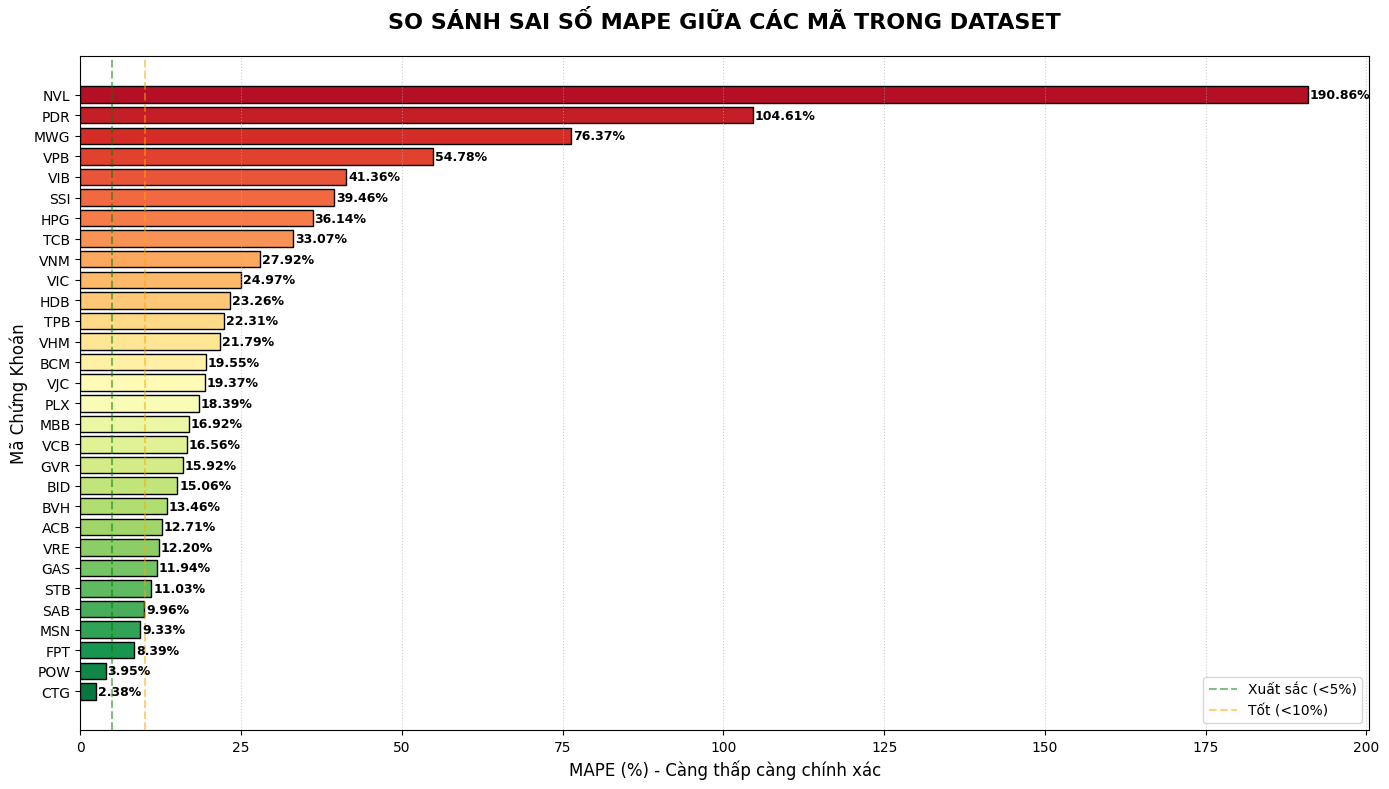


✅ MAPE TRUNG BÌNH TOÀN BỘ: 30.47%


In [19]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# ============================================================
# CẤU HÌNH KIỂM THỬ
# ============================================================
MODEL_PATH = '/kaggle/working/best_bilstm_vnm.keras'
# Hãy đảm bảo đường dẫn này chính xác với môi trường Kaggle của bạn
DATA_DIR = '/kaggle/input/datasets/thangtranquang/stock-vn30-vietnam/' 
TIME_STEPS = 30
FEATURES = ['open', 'high', 'low', 'close', 'volume']
TARGET_IDX = 3 

# 1. Load model
print(f"--- Đang tải model từ: {MODEL_PATH} ---")
model = load_model(MODEL_PATH)

def evaluate_stock_file(file_path):
    try:
        df = pd.read_csv(file_path)
        df.columns = [c.lower() for c in df.columns]
        if 'date' in df.columns:
            df['date'] = pd.to_datetime(df['date'])
            df = df.sort_values('date')
            
        data = df[FEATURES].values
        # Xử lý bỏ qua các giá trị <= 0 để tránh lỗi MAPE inf
        data = data[~np.any(data <= 0, axis=1)]
        
        if len(data) < (TIME_STEPS + FORECAST_HORIZON + 10): return None
            
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaled_data = scaler.fit_transform(data)
        
        X, y_true_scaled = [], []
        for i in range(len(scaled_data) - TIME_STEPS - FORECAST_HORIZON + 1):
            X.append(scaled_data[i : i + TIME_STEPS])
            y_true_scaled.append(scaled_data[i + TIME_STEPS : i + TIME_STEPS + FORECAST_HORIZON, TARGET_IDX])
            
        X, y_true_scaled = np.array(X), np.array(y_true_scaled)
        y_pred_scaled = model.predict(X, verbose=0, batch_size=512)
        
        def inverse_transform_y(y_scaled):
            y_inv = []
            # Chỉ lấy 100 mẫu cuối để tính toán nhanh và đại diện cho xu hướng gần đây
            samples = y_scaled[-100:] 
            for sample in samples:
                dummy = np.zeros((FORECAST_HORIZON, len(FEATURES)))
                dummy[:, TARGET_IDX] = sample
                y_inv.append(scaler.inverse_transform(dummy)[:, TARGET_IDX])
            return np.array(y_inv)

        y_true = inverse_transform_y(y_true_scaled)
        y_pred = inverse_transform_y(y_pred_scaled)
        
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        return rmse, mape
    except:
        return None

# ============================================================
# CHẠY KIỂM THỬ & THU THẬP DỮ LIỆU
# ============================================================
all_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
results = []

print(f"\n{'Ticker':<10} | {'RMSE':<15} | {'MAPE (%)':<10}")
print("-" * 45)

for file in all_files:
    ticker = os.path.basename(file).replace(".csv", "")
    # Loại bỏ VN30 vì đây là chỉ số, không phải giá cổ phiếu (tránh lệch thang đo)
    if "VN30" in ticker.upper(): continue 
    
    metrics = evaluate_stock_file(file)
    if metrics:
        rmse, mape = metrics
        results.append({"Ticker": ticker, "RMSE": rmse, "MAPE": mape})
        print(f"{ticker:<10} | {rmse:15,.2f} | {mape:10.2f}%")

# ============================================================
# VẼ BIỂU ĐỒ TỔNG HỢP
# ============================================================
if results:
    df_results = pd.DataFrame(results).sort_values('MAPE')

    plt.figure(figsize=(14, 8))
    # Vẽ biểu đồ cột ngang
    colors = sns.color_palette("RdYlGn_r", len(df_results)) # Màu đỏ cho MAPE cao, xanh cho MAPE thấp
    bars = plt.barh(df_results['Ticker'], df_results['MAPE'], color=colors, edgecolor='black')
    
    # Thêm đường giới hạn 5% và 10% để đánh giá
    plt.axvline(x=5, color='green', linestyle='--', alpha=0.5, label='Xuất sắc (<5%)')
    plt.axvline(x=10, color='orange', linestyle='--', alpha=0.5, label='Tốt (<10%)')
    
    plt.title("SO SÁNH SAI SỐ MAPE GIỮA CÁC MÃ TRONG DATASET", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel("MAPE (%) - Càng thấp càng chính xác", fontsize=12)
    plt.ylabel("Mã Chứng Khoán", fontsize=12)
    plt.legend()
    plt.grid(axis='x', linestyle=':', alpha=0.6)

    # Hiển thị giá trị số trên từng cột
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.3, bar.get_y() + bar.get_height()/2, 
                 f'{width:.2f}%', va='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print(f"\n✅ MAPE TRUNG BÌNH TOÀN BỘ: {df_results['MAPE'].mean():.2f}%")